In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

x, labels_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

x = StandardScaler().fit_transform(x)

In [26]:
db =DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(x)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)

Jumlah cluster: 2
Jumlah noise: 0


In [ ]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(x, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


Estimated number of clusters: 2


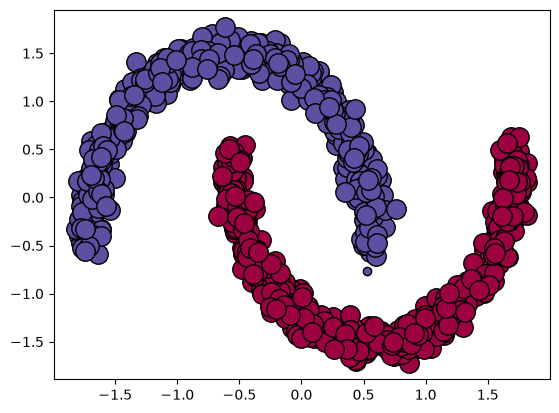

In [28]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = x[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col),
             markeredgecolor="k",
             markersize=14)

    xy = x[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col),
             markeredgecolor="k",
             markersize=6)

print(f"Estimated number of clusters: {n_clusters}")
plt.show()

In [29]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = db.fit_predict(x)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        print(
            f"eps={eps}, "
            f"min_samples={min_samples}, "
            f"clusters={n_clusters}, "
            f"noise={n_noise}"
        )

eps=0.05, min_samples=3, clusters=67, noise=197
eps=0.05, min_samples=10, clusters=0, noise=1000
eps=0.05, min_samples=20, clusters=0, noise=1000
eps=0.1, min_samples=3, clusters=3, noise=18
eps=0.1, min_samples=10, clusters=9, noise=63
eps=0.1, min_samples=20, clusters=6, noise=844
eps=0.3, min_samples=3, clusters=2, noise=0
eps=0.3, min_samples=10, clusters=2, noise=0
eps=0.3, min_samples=20, clusters=2, noise=0
eps=0.5, min_samples=3, clusters=1, noise=0
eps=0.5, min_samples=10, clusters=1, noise=0
eps=0.5, min_samples=20, clusters=2, noise=0


In [30]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(x)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        print(f"\neps={eps}, min_samples={min_samples}")
        print(f"Clusters: {n_clusters}")
        print(f"Noise: {n_noise}")

        if n_clusters > 1:
            print(f"Homogeneity: {metrics.homogeneity_score(label_true, labels):.3f}")
            print(f"Completeness: {metrics.completeness_score(label_true, labels):.3f}")
            print(f"V-measure: {metrics.v_measure_score(label_true, labels):.3f}")
            print(f"ARI: {metrics.adjusted_rand_score(label_true, labels):.3f}")
            print(f"AMI: {metrics.adjusted_mutual_info_score(label_true, labels):.3f}")
            print(f"Silhouette: {metrics.silhouette_score(x, labels):.3f}")


eps=0.05, min_samples=3
Clusters: 67
Noise: 197
Homogeneity: 0.804
Completeness: 0.155
V-measure: 0.260
ARI: 0.033
AMI: 0.246
Silhouette: 0.078

eps=0.05, min_samples=10
Clusters: 0
Noise: 1000

eps=0.05, min_samples=20
Clusters: 0
Noise: 1000

eps=0.1, min_samples=3
Clusters: 3
Noise: 18
Homogeneity: 0.983
Completeness: 0.708
V-measure: 0.824
ARI: 0.854
AMI: 0.823
Silhouette: 0.138

eps=0.1, min_samples=10
Clusters: 9
Noise: 63
Homogeneity: 0.939
Completeness: 0.358
V-measure: 0.519
ARI: 0.435
AMI: 0.517
Silhouette: 0.184

eps=0.1, min_samples=20
Clusters: 6
Noise: 844
Homogeneity: 0.157
Completeness: 0.153
V-measure: 0.155
ARI: 0.010
AMI: 0.152
Silhouette: -0.409

eps=0.3, min_samples=3
Clusters: 2
Noise: 0
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
ARI: 1.000
AMI: 1.000
Silhouette: 0.392

eps=0.3, min_samples=10
Clusters: 2
Noise: 0
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
ARI: 1.000
AMI: 1.000
Silhouette: 0.392

eps=0.3, min_samples=20
Clusters: 2
Noise